In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import cv2

import numpy as np
from matplotlib.colors import ListedColormap


In [2]:
# Load the image
with rasterio.open("../src/trimmed-sentinel-2-data/trimmed_S2A_17TLJ_20190714_0_L2A_TCI.tif") as src:
    image = src.read()
    height, width = image.shape[1], image.shape[2]
    transform = src.transform
    crs = src.crs

# Prepare image for processing
img = np.transpose(image, (1, 2, 0))
img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

In [3]:
# Create grayscale image
gray = cv2.cvtColor(img_8bit, cv2.COLOR_RGB2GRAY)

# param1 - A stronger bilateral filter will blur more details
filtered = cv2.bilateralFilter(gray, 5, 50, 50)

# param2 - Apply Canny edge detection with less sensitivity (higher thresholds)
edges = cv2.Canny(filtered, 30, 100)

# param3 - Dilate edges to connect any gaps - More dilation will connect edges that are further apart
kernel = np.ones((2, 2), np.uint8)
dilated_edges = cv2.dilate(edges, kernel, iterations=1)

In [4]:
# Find contours
# cv2.RETR_TREE - identify hierarchical relationships between contours
contours, _ = cv2.findContours(dilated_edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# param4 - Filter contours by area - Increasing the minimum area will filter out more of the smaller detected fields
min_area = 24  # Minimum contour area in pixels
max_area = height * width * 0.1  # Max 10% of image
filtered_contours = [cnt for cnt in contours if min_area < cv2.contourArea(cnt) < max_area]

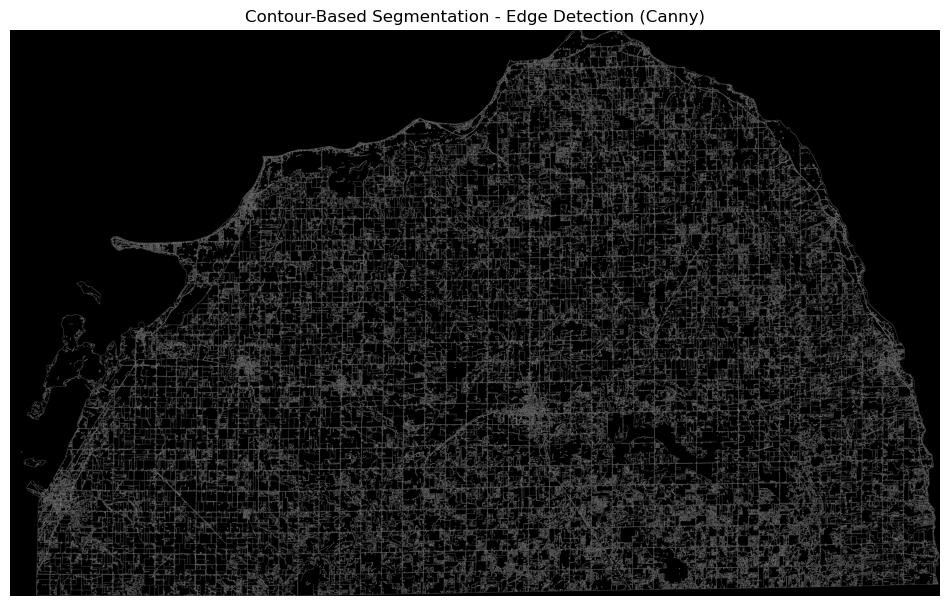

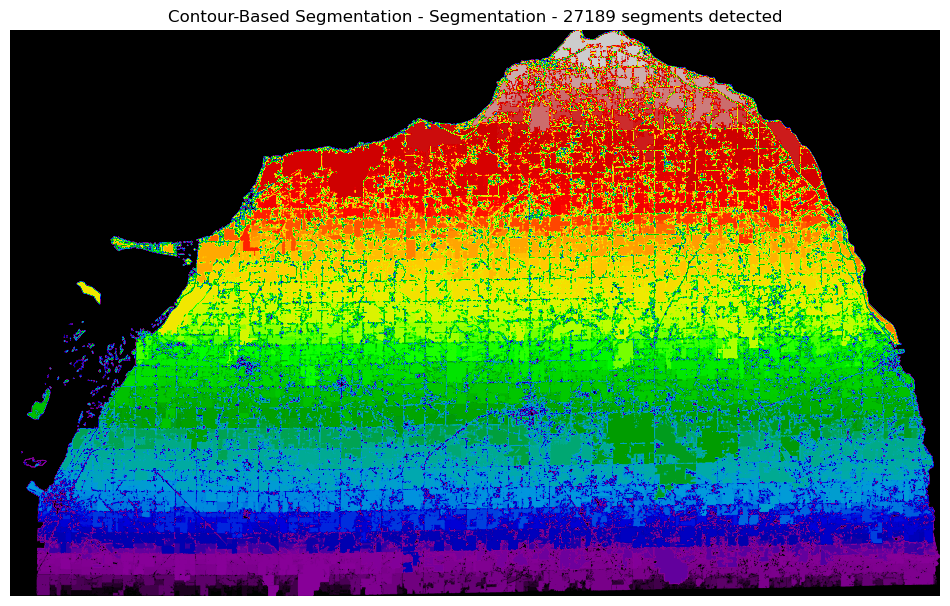

In [15]:
# Create segmentation map
segmentation = np.zeros((height, width), dtype=np.int32)
for i, contour in enumerate(filtered_contours):
    cv2.drawContours(segmentation, [contour], 0, i+1, -1)  # Fill with label i+1


# Visualize the edge detection and segmentation results side by side
plt.figure(figsize=(12, 12))
plt.imshow(edges, cmap='gray')
plt.title("Contour-Based Segmentation - Edge Detection (Canny)")
plt.axis('off')

plt.show()

# Display segmentation map with a colormap for better distinction
plt.figure(figsize=(12, 12))
plt.imshow(segmentation, cmap='nipy_spectral')
plt.title(f"Contour-Based Segmentation - Segmentation - {len(filtered_contours)} segments detected")
plt.axis('off')

plt.show()

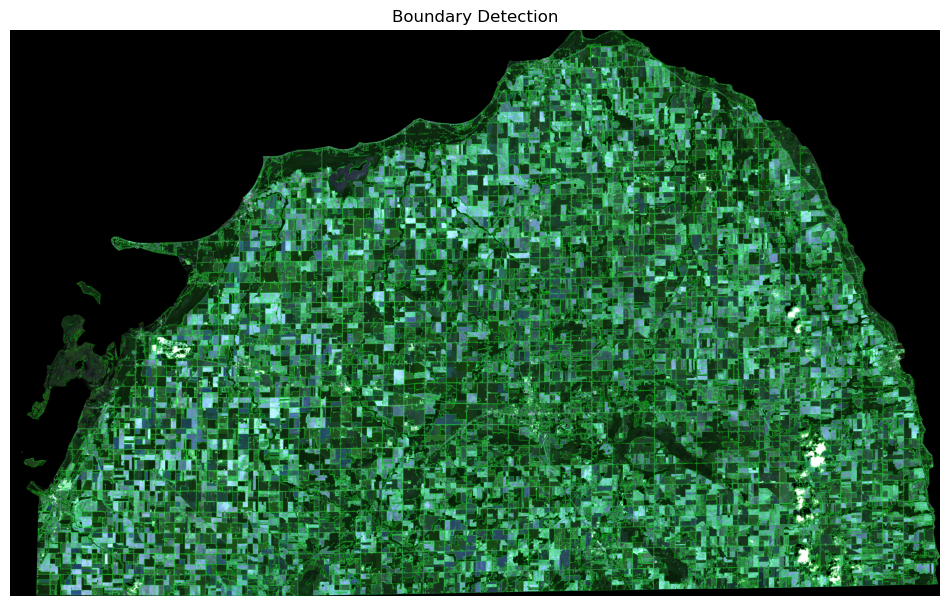

In [12]:
# Create boundary image
boundary_image = img_8bit.copy()
cv2.drawContours(boundary_image, filtered_contours, -1, (0, 255, 0), 1)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(boundary_image, cv2.COLOR_BGR2RGB))
plt.title("Contour-Based Segmentation - Boundary Detection")
plt.axis('off')
plt.show()